# HGT para detecção de fraude em grafo heterogêneo

Notebook organizado para focar nos experimentos de deep learning: arquitetura HGT, conexão residual, LayerNorm, Dropout, loss e otimizador.


## 1. Carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

drive.mount('/content/drive')

caminho = "/content/drive/MyDrive/Aula_llm/Trabalho final/Dados/IBM/"

X_train_balanceado = pd.read_csv(caminho + 'dados_trans_treino.csv')
X_val_processado = pd.read_csv(caminho + 'dados_trans_validacao.csv')
X_test_processado = pd.read_csv(caminho + 'dados_trans_teste.csv')
X_accounts = pd.read_csv(caminho + 'LI-Small_accounts.csv')

print(X_train_balanceado.shape)
print(X_val_processado.shape)
print(X_test_processado.shape)
print(X_accounts.shape)

Mounted at /content/drive
(27450, 43)
(5882, 43)
(5883, 43)
(712688, 5)


In [2]:
print(X_train_balanceado.columns)
print(X_accounts.columns)

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering', 'ano', 'mes',
       'dia_mes', 'hora', 'minuto', 'dia_semana', 'semana_ano', 'semana_mes',
       'fim_de_semana', 'tipo_semana', 'periodo_dia', 'periodo_dia_3',
       'inicio_mes', 'fim_mes', 'hora_sin', 'hora_cos', 'dia_semana_sin',
       'dia_semana_cos', 'mes_sin', 'mes_cos', 'dif_valor', 'dif_valor_abs',
       'razao_pago_recebido', 'amount_paid_log', 'amount_received_log',
       'mesmo_banco', 'mesma_conta', 'mesma_moeda', 'pagamento_reinvestment',
       'source_account_id', 'target_account_id', 'transaction_id'],
      dtype='object')
Index(['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name'], dtype='object')


## 2. Preparação dos atributos das transações

A normalização é ajustada apenas no treino. Validação e teste usam o mesmo `scaler`, evitando vazamento de informação.

In [3]:
from sklearn.preprocessing import StandardScaler

cols = [
    'amount_paid_log',
    'amount_received_log',
    'razao_pago_recebido'
]

scaler = StandardScaler()

X_train_balanceado[cols] = scaler.fit_transform(X_train_balanceado[cols])
X_val_processado[cols] = scaler.transform(X_val_processado[cols])
X_test_processado[cols] = scaler.transform(X_test_processado[cols])

In [4]:
cat_cols = [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

num_cols = [
    "amount_paid_log",
    "amount_received_log",
    "dif_valor",
    "dif_valor_abs",
    "razao_pago_recebido",
    "mesmo_banco",
    "mesma_conta",
    "mesma_moeda",
    "pagamento_reinvestment",
    "hora_sin",
    "hora_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "mes_sin",
    "mes_cos",
    "fim_de_semana",
    "inicio_mes",
    "fim_mes",
    "semana_mes"
]

X_train_edges = pd.get_dummies(
    X_train_balanceado[num_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

X_val_edges = pd.get_dummies(
    X_val_processado[num_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

X_test_edges = pd.get_dummies(
    X_test_processado[num_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

# Validação e teste precisam ter exatamente as mesmas colunas do treino.
X_val_edges = X_val_edges.reindex(columns=X_train_edges.columns, fill_value=0)
X_test_edges = X_test_edges.reindex(columns=X_train_edges.columns, fill_value=0)

print(X_train_edges.shape, X_val_edges.shape, X_test_edges.shape)

(27450, 56) (5882, 56) (5883, 56)


In [5]:
def limpar_features_edges(X_edges):
    X_edges = X_edges.copy()

    # Converte booleanos e categorias codificadas para número.
    X_edges = X_edges.apply(pd.to_numeric, errors="coerce")

    # Remove NaN e infinitos.
    X_edges = X_edges.replace([np.inf, -np.inf], 0)
    X_edges = X_edges.fillna(0)

    # Garante tipo compatível com PyTorch.
    X_edges = X_edges.astype(np.float32)

    return X_edges

X_train_edges = limpar_features_edges(X_train_edges)
X_val_edges = limpar_features_edges(X_val_edges)
X_test_edges = limpar_features_edges(X_test_edges)

print(X_train_edges.dtypes.value_counts())

float32    56
Name: count, dtype: int64


## 3. Construção do grafo heterogêneo

Nós: `account`, `bank` e `entity`.

Aresta principal: `account -> account`, representando a transação. Essa aresta recebe `edge_attr` e `edge_label`.

In [6]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 802.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.0 MB/s eta 0:00:00


In [7]:
import torch
from torch_geometric.data import HeteroData
from sklearn.preprocessing import LabelEncoder

In [8]:
def criar_grafo_heterogeneo(df_trans, df_accounts, X_edges):
    df_trans = df_trans.copy()
    df_accounts = df_accounts.copy()

    df_accounts["account_id"] = (
        df_accounts["Bank ID"].astype(str) + "_" +
        df_accounts["Account Number"].astype(str)
    )

    df_trans["source_account_id"] = (
        df_trans["From Bank"].astype(str) + "_" +
        df_trans["Account"].astype(str)
    )

    df_trans["target_account_id"] = (
        df_trans["To Bank"].astype(str) + "_" +
        df_trans["Account.1"].astype(str)
    )

    all_accounts = pd.concat([
        df_trans["source_account_id"],
        df_trans["target_account_id"]
    ]).unique()

    all_banks = pd.concat([
        df_trans["From Bank"].astype(str),
        df_trans["To Bank"].astype(str)
    ]).unique()

    accounts_usadas = df_accounts[df_accounts["account_id"].isin(all_accounts)].copy()
    all_entities = accounts_usadas["Entity ID"].astype(str).unique()

    account_encoder = LabelEncoder()
    bank_encoder = LabelEncoder()
    entity_encoder = LabelEncoder()

    account_encoder.fit(all_accounts)
    bank_encoder.fit(all_banks)

    if len(all_entities) > 0:
        entity_encoder.fit(all_entities)
    else:
        entity_encoder.fit(["entidade_desconhecida"])

    data = HeteroData()

    data["account"].num_nodes = len(account_encoder.classes_)
    data["bank"].num_nodes = len(bank_encoder.classes_)
    data["entity"].num_nodes = len(entity_encoder.classes_)

    features_cols = [
        "amount_paid_log",
        "amount_received_log",
        "razao_pago_recebido",
        "mesmo_banco",
        "mesma_conta",
        "mesma_moeda",
        "pagamento_reinvestment"
    ]

    features_cols = [c for c in features_cols if c in df_trans.columns]

    account_features = pd.DataFrame(index=account_encoder.classes_)

    src_aggs = df_trans.groupby("source_account_id")[features_cols].mean()
    dst_aggs = df_trans.groupby("target_account_id")[features_cols].mean()

    account_features = account_features.join(src_aggs, how="left", rsuffix="_src")
    account_features = account_features.join(dst_aggs, how="left", rsuffix="_dst")
    account_features = account_features.fillna(0).astype(np.float32)

    data["account"].x = torch.from_numpy(account_features.to_numpy(dtype=np.float32))

    # Bancos e entidades recebem feature constante. O modelo diferencia esses nós pelas conexões.
    data["bank"].x = torch.ones((len(bank_encoder.classes_), 1), dtype=torch.float32)
    data["entity"].x = torch.ones((len(entity_encoder.classes_), 1), dtype=torch.float32)

    # Aresta principal: conta origem -> conta destino.
    src = account_encoder.transform(df_trans["source_account_id"])
    dst = account_encoder.transform(df_trans["target_account_id"])

    rel = ("account", "transfere_para", "account")

    data[rel].edge_index = torch.tensor([src, dst], dtype=torch.long)
    data[rel].edge_attr = torch.from_numpy(X_edges.to_numpy(dtype=np.float32))
    data[rel].edge_label = torch.tensor(df_trans["Is Laundering"].values, dtype=torch.long)

    # Arestas conta -> banco e banco -> conta.
    source_accounts = df_trans[["source_account_id", "From Bank"]].rename(
        columns={"source_account_id": "account_id", "From Bank": "bank_id"}
    )

    target_accounts = df_trans[["target_account_id", "To Bank"]].rename(
        columns={"target_account_id": "account_id", "To Bank": "bank_id"}
    )

    conta_banco = pd.concat([source_accounts, target_accounts]).drop_duplicates()
    conta_banco["bank_id"] = conta_banco["bank_id"].astype(str)

    acc_idx = account_encoder.transform(conta_banco["account_id"])
    bank_idx = bank_encoder.transform(conta_banco["bank_id"])

    data["account", "pertence_ao_banco", "bank"].edge_index = torch.tensor(
        [acc_idx, bank_idx], dtype=torch.long
    )

    data["bank", "possui_conta", "account"].edge_index = torch.tensor(
        [bank_idx, acc_idx], dtype=torch.long
    )

    # Arestas conta -> entidade e entidade -> conta.
    conta_entidade = accounts_usadas[["account_id", "Entity ID"]].drop_duplicates()
    conta_entidade["Entity ID"] = conta_entidade["Entity ID"].astype(str)

    if len(conta_entidade) > 0:
        acc_ent_idx = account_encoder.transform(conta_entidade["account_id"])
        ent_idx = entity_encoder.transform(conta_entidade["Entity ID"])

        data["account", "pertence_a_entidade", "entity"].edge_index = torch.tensor(
            [acc_ent_idx, ent_idx], dtype=torch.long
        )

        data["entity", "possui_conta", "account"].edge_index = torch.tensor(
            [ent_idx, acc_ent_idx], dtype=torch.long
        )

    return data, account_encoder, bank_encoder, entity_encoder

In [9]:
grafo_treino, account_encoder, bank_encoder, entity_encoder = criar_grafo_heterogeneo(
    X_train_balanceado,
    X_accounts,
    X_train_edges
)

grafo_validacao, _, _, _ = criar_grafo_heterogeneo(
    X_val_processado,
    X_accounts,
    X_val_edges
)

grafo_teste, _, _, _ = criar_grafo_heterogeneo(
    X_test_processado,
    X_accounts,
    X_test_edges
)

print(grafo_treino)

/tmp/ipykernel_4970/685187770.py:84: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data[rel].edge_index = torch.tensor([src, dst], dtype=torch.long)


HeteroData(
  account={
    num_nodes=44240,
    x=[44240, 14],
  },
  bank={
    num_nodes=3193,
    x=[3193, 1],
  },
  entity={
    num_nodes=37118,
    x=[37118, 1],
  },
  (account, transfere_para, account)={
    edge_index=[2, 27450],
    edge_attr=[27450, 56],
    edge_label=[27450],
  },
  (account, pertence_ao_banco, bank)={ edge_index=[2, 44240] },
  (bank, possui_conta, account)={ edge_index=[2, 44240] },
  (account, pertence_a_entidade, entity)={ edge_index=[2, 44240] },
  (entity, possui_conta, account)={ edge_index=[2, 44240] }
)


In [10]:
rel = ("account", "transfere_para", "account")

print(grafo_treino[rel].edge_index.shape)
print(grafo_treino[rel].edge_attr.shape)
print(grafo_treino[rel].edge_label.shape)
print(torch.bincount(grafo_treino[rel].edge_label))

torch.Size([2, 27450])
torch.Size([27450, 56])
torch.Size([27450])
tensor([24955,  2495])


## 4. Modelo HGT

HGT base e as variações com residual, LayerNorm, Dropout e decoder relacional. Assim não é necessário manter duas classes diferentes de encoder.

In [11]:
import random
import copy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import HGTConv, Linear
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


def definir_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def criar_normalizacao(dim, usar_layernorm=True):
    return nn.LayerNorm(dim) if usar_layernorm else nn.Identity()


def aplicar_ativacao(x, ativacao):
    if ativacao == "gelu":
        return F.gelu(x)
    if ativacao == "relu":
        return F.relu(x)
    raise ValueError("ativacao deve ser 'relu' ou 'gelu'")

In [12]:
class HGTEncoderUnificado(nn.Module):
    def __init__(
        self,
        metadata,
        hidden_channels=64,
        num_heads=4,
        num_layers=2,
        dropout=0.3,
        residual=False,
        usar_layernorm=False,
        ativacao="relu"
    ):
        super().__init__()

        self.node_types = metadata[0]
        self.residual = residual
        self.usar_layernorm = usar_layernorm
        self.ativacao = ativacao
        self.dropout = nn.Dropout(dropout)

        self.projecoes = nn.ModuleDict({
            node_type: Linear(-1, hidden_channels)
            for node_type in self.node_types
        })

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(
                HGTConv(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    metadata=metadata,
                    heads=num_heads
                )
            )

            self.norms.append(
                nn.ModuleDict({
                    node_type: criar_normalizacao(hidden_channels, usar_layernorm)
                    for node_type in self.node_types
                })
            )

    def forward(self, x_dict, edge_index_dict):
        x_dict = {
            node_type: aplicar_ativacao(self.projecoes[node_type](x), self.ativacao)
            for node_type, x in x_dict.items()
        }

        for conv, norm_dict in zip(self.convs, self.norms):
            h_dict = conv(x_dict, edge_index_dict)
            novo_x_dict = {}

            for node_type, x in x_dict.items():
                if node_type not in h_dict:
                    novo_x_dict[node_type] = x
                    continue

                h = aplicar_ativacao(h_dict[node_type], self.ativacao)
                h = self.dropout(h)

                # Quando residual=False, o modelo se comporta como o HGT base.
                if self.residual:
                    h = x + h

                h = norm_dict[node_type](h)
                novo_x_dict[node_type] = h

            x_dict = novo_x_dict

        return x_dict


class ClassificadorArestaUnificado(nn.Module):
    def __init__(
        self,
        hidden_channels,
        edge_attr_dim,
        decoder="simples",
        dropout=0.3,
        usar_layernorm=False,
        ativacao="relu"
    ):
        super().__init__()

        if decoder not in ["simples", "relacional"]:
            raise ValueError("decoder deve ser 'simples' ou 'relacional'")

        self.decoder = decoder
        self.ativacao = ativacao

        if decoder == "simples":
            input_dim = hidden_channels * 2 + edge_attr_dim
        else:
            input_dim = hidden_channels * 4 + edge_attr_dim

        self.linear1 = nn.Linear(input_dim, 128)
        self.norm1 = criar_normalizacao(128, usar_layernorm)
        self.drop1 = nn.Dropout(dropout)

        self.linear2 = nn.Linear(128, 64)
        self.norm2 = criar_normalizacao(64, usar_layernorm)
        self.drop2 = nn.Dropout(dropout)

        self.saida = nn.Linear(64, 1)

    def forward(self, z_src, z_dst, edge_attr):
        if self.decoder == "simples":
            entrada = torch.cat([z_src, z_dst, edge_attr], dim=1)
        else:
            diferenca = torch.abs(z_src - z_dst)
            produto = z_src * z_dst
            entrada = torch.cat([z_src, z_dst, diferenca, produto, edge_attr], dim=1)

        x = self.linear1(entrada)
        x = self.norm1(x)
        x = aplicar_ativacao(x, self.ativacao)
        x = self.drop1(x)

        x = self.linear2(x)
        x = self.norm2(x)
        x = aplicar_ativacao(x, self.ativacao)
        x = self.drop2(x)

        return self.saida(x).view(-1)


class HGTFraudModel(nn.Module):
    def __init__(
        self,
        metadata,
        hidden_channels,
        edge_attr_dim,
        num_heads=4,
        num_layers=2,
        dropout=0.3,
        residual=False,
        usar_layernorm=False,
        decoder="simples",
        ativacao="relu"
    ):
        super().__init__()

        self.encoder = HGTEncoderUnificado(
            metadata=metadata,
            hidden_channels=hidden_channels,
            num_heads=num_heads,
            num_layers=num_layers,
            dropout=dropout,
            residual=residual,
            usar_layernorm=usar_layernorm,
            ativacao=ativacao
        )

        self.classificador = ClassificadorArestaUnificado(
            hidden_channels=hidden_channels,
            edge_attr_dim=edge_attr_dim,
            decoder=decoder,
            dropout=dropout,
            usar_layernorm=usar_layernorm,
            ativacao=ativacao
        )

    def forward(self, data):
        rel = ("account", "transfere_para", "account")

        z_dict = self.encoder(data.x_dict, data.edge_index_dict)

        edge_index = data[rel].edge_index
        edge_attr = data[rel].edge_attr

        src = edge_index[0]
        dst = edge_index[1]

        z_src = z_dict["account"][src]
        z_dst = z_dict["account"][dst]

        return self.classificador(z_src, z_dst, edge_attr)

### Funções de loss e criação do modelo

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma

        return (alpha_t * focal_weight * bce_loss).mean()


def criar_modelo_hgt(
    grafo,
    hidden_channels=64,
    num_heads=4,
    num_layers=2,
    dropout=0.3,
    residual=False,
    usar_layernorm=False,
    decoder="simples",
    ativacao="relu",
    device="cpu"
):
    rel = ("account", "transfere_para", "account")
    edge_attr_dim = grafo[rel].edge_attr.shape[1]

    model = HGTFraudModel(
        metadata=grafo.metadata(),
        hidden_channels=hidden_channels,
        edge_attr_dim=edge_attr_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout,
        residual=residual,
        usar_layernorm=usar_layernorm,
        decoder=decoder,
        ativacao=ativacao
    )

    return model.to(device)


def criar_loss(nome_loss, pos_weight=10.0, alpha=0.75, gamma=2.0, device="cpu"):
    if nome_loss == "bce_ponderada":
        peso = torch.tensor([float(pos_weight)], dtype=torch.float32, device=device)
        return nn.BCEWithLogitsLoss(pos_weight=peso)

    if nome_loss == "bce":
        return nn.BCEWithLogitsLoss()

    if nome_loss == "focal":
        return FocalLoss(alpha=alpha, gamma=gamma)

    raise ValueError("nome_loss deve ser 'bce_ponderada', 'bce' ou 'focal'")


def criar_otimizador(model, nome_otimizador="adamw", lr=0.01, weight_decay=1e-4):
    if nome_otimizador == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if nome_otimizador == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    raise ValueError("nome_otimizador deve ser 'adam' ou 'adamw'")

## 5. Treinamento e avaliação

In [14]:
@torch.no_grad()
def avaliar(model, data, tipo="teste", threshold=0.5, imprimir=True):
    model.eval()

    rel = ("account", "transfere_para", "account")

    logits = model(data)
    probs = torch.sigmoid(logits)

    y_true = data[rel].edge_label.detach().cpu().numpy()
    y_prob = probs.detach().cpu().numpy()
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = 0

    try:
        auprc = average_precision_score(y_true, y_prob)
    except ValueError:
        auprc = 0

    metricas = {
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "auprc": auprc
    }

    if imprimir:
        print(
            f"{tipo}: "
            f"acc={acc:.3f} | precision={precision:.3f} | "
            f"recall={recall:.3f} | f1={f1:.3f} | "
            f"auc={auc:.3f} | auprc={auprc:.3f}"
        )

    return metricas


def treinar_modelo(
    model,
    grafo_treino,
    grafo_validacao,
    criterion,
    optimizer,
    num_epochs=50,
    threshold=0.5,
    clip_grad=2.0
):
    rel = ("account", "transfere_para", "account")
    historico = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(grafo_treino)
        y = grafo_treino[rel].edge_label.float()

        loss = criterion(logits, y)
        loss.backward()

        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)

        optimizer.step()

        registro = {"epoch": epoch, "loss": loss.item()}

        if epoch % 5 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
            train_metrics = avaliar(model, grafo_treino, "Treino", threshold=threshold)
            val_metrics = avaliar(model, grafo_validacao, "Validação", threshold=threshold)
            print("-" * 60)

            registro.update({f"train_{k}": v for k, v in train_metrics.items()})
            registro.update({f"val_{k}": v for k, v in val_metrics.items()})

        historico.append(registro)

    return model, pd.DataFrame(historico)

In [15]:
def plotar_metricas(metricas, titulo="Desempenho do modelo", salvar_em=None):
    plt.figure(figsize=(6, 3.2))
    cores = ['royalblue', 'darkorange', 'limegreen', 'crimson', 'mediumpurple']

    nomes = list(metricas.keys())
    valores = [float(v) for v in metricas.values()]

    barras = plt.barh(nomes, valores,color=cores, height=0.45, edgecolor="black")

    plt.xlim(0, 1)
    plt.xlabel("Valor da métrica")
    plt.title(titulo)

    for barra in barras:
        largura = barra.get_width()
        plt.text(
            largura + 0.01,
            barra.get_y() + barra.get_height() / 2,
            f"{largura:.3f}",
            va="center",
            fontsize=9
        )

    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()

    if salvar_em is not None:
        plt.savefig(salvar_em, dpi=300, bbox_inches="tight")

    plt.show()

## 6. Configuração do experimento

Mude apenas o dicionário abaixo para reproduzir as variações do trabalho. A classe do modelo continua sendo a mesma.

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

grafo_treino = grafo_treino.to(device)
grafo_validacao = grafo_validacao.to(device)
grafo_teste = grafo_teste.to(device)

rel = ("account", "transfere_para", "account")
edge_attr_dim = grafo_treino[rel].edge_attr.shape[1]
metadata = grafo_treino.metadata()

print("edge_attr_dim:", edge_attr_dim)
print("metadata:", metadata)

cpu
edge_attr_dim: 56
metadata: (['account', 'bank', 'entity'], [('account', 'transfere_para', 'account'), ('account', 'pertence_ao_banco', 'bank'), ('bank', 'possui_conta', 'account'), ('account', 'pertence_a_entidade', 'entity'), ('entity', 'possui_conta', 'account')])


In [17]:
# Escolha uma configuração por vez.
# Exemplos:
# 1) HGT base: residual=False, usar_layernorm=False, decoder="simples", ativacao="relu"
# 2) HGT residual: residual=True, usar_layernorm=False, decoder="relacional", ativacao="gelu"
# 3) HGT residual + LayerNorm + Dropout: residual=True, usar_layernorm=True, decoder="relacional", ativacao="gelu"
# 4) Focal Loss: mude loss para "focal"

config = {
    "nome": "AdamW + BCE ponderada + HGT residual + LayerNorm + Dropout",
    "seed": 42,
    "hidden_channels": 64,
    "num_heads": 4,
    "num_layers": 2,
    "dropout": 0.3,
    "residual": True,
    "usar_layernorm": True,
    "decoder": "relacional",
    "ativacao": "gelu",
    "loss": "bce_ponderada",
    "pos_weight": 10.0,
    "otimizador": "adamw",
    "lr": 0.01,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "threshold": 0.5
}

In [18]:
def rodar_experimento(config):
    definir_seed(config.get("seed", 42))

    model = criar_modelo_hgt(
        grafo=grafo_treino,
        hidden_channels=config.get("hidden_channels", 64),
        num_heads=config.get("num_heads", 4),
        num_layers=config.get("num_layers", 2),
        dropout=config.get("dropout", 0.3),
        residual=config.get("residual", False),
        usar_layernorm=config.get("usar_layernorm", False),
        decoder=config.get("decoder", "simples"),
        ativacao=config.get("ativacao", "relu"),
        device=device
    )

    criterion = criar_loss(
        nome_loss=config.get("loss", "bce_ponderada"),
        pos_weight=config.get("pos_weight", 10.0),
        alpha=config.get("alpha", 0.75),
        gamma=config.get("gamma", 2.0),
        device=device
    )

    optimizer = criar_otimizador(
        model,
        nome_otimizador=config.get("otimizador", "adamw"),
        lr=config.get("lr", 0.01),
        weight_decay=config.get("weight_decay", 1e-4)
    )

    print("Experimento:", config["nome"])
    print(model)
    print("Loss:", config.get("loss"))
    print("Otimizador:", config.get("otimizador"))
    print("Épocas:", config.get("num_epochs"))
    print("-" * 60)

    model, historico = treinar_modelo(
        model=model,
        grafo_treino=grafo_treino,
        grafo_validacao=grafo_validacao,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=config.get("num_epochs", 50),
        threshold=config.get("threshold", 0.5)
    )

    test_metrics = avaliar(
        model,
        grafo_teste,
        tipo="Teste",
        threshold=config.get("threshold", 0.5)
    )

    return model, historico, test_metrics

In [19]:
model, historico, test_metrics = rodar_experimento(config)
test_metrics

Experimento: AdamW + BCE ponderada + HGT residual + LayerNorm + Dropout
HGTFraudModel(
  (encoder): HGTEncoderUnificado(
    (dropout): Dropout(p=0.3, inplace=False)
    (projecoes): ModuleDict(
      (account): Linear(-1, 64, bias=True)
      (bank): Linear(-1, 64, bias=True)
      (entity): Linear(-1, 64, bias=True)
    )
    (convs): ModuleList(
      (0-1): 2 x HGTConv(-1, 64, heads=4)
    )
    (norms): ModuleList(
      (0-1): 2 x ModuleDict(
        (account): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (bank): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (entity): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (classificador): ClassificadorArestaUnificado(
    (linear1): Linear(in_features=312, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (drop1): Dropout(p=0.3, inplace=False)
    (linear2): Linear(in_features=128, out_features=64, bias=True)
    (norm2): LayerNorm(

{'acc': 0.9192588815230325,
 'precision': 0.5462962962962963,
 'recall': 0.6616822429906543,
 'f1': 0.5984784446322908,
 'auc': np.float64(0.9308893533437254),
 'auprc': np.float64(0.5796491519367012)}

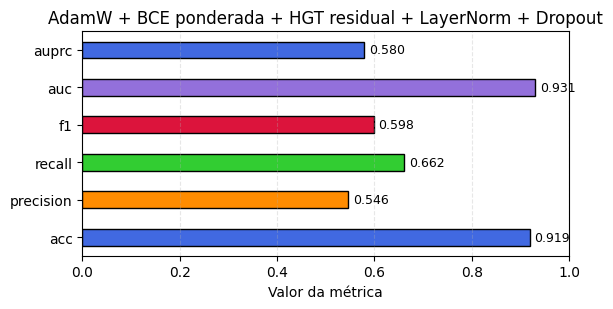

In [20]:
nome_arquivo = config["nome"].replace(" ", "_").replace("+", "mais").replace("/", "_")
salvar_em = caminho + f"metricas_{nome_arquivo}.png"

plotar_metricas(
    test_metrics,
    titulo=config["nome"],
    salvar_em=salvar_em
)

## 7. Configurações usadas na comparação

Use este bloco caso queira rodar os principais experimentos do trabalho de forma organizada. Para economizar tempo, também é possível copiar uma configuração para o bloco anterior e rodar apenas uma por vez.

In [21]:
experimentos = [
    {
        "nome": "Adam + BCE ponderada + HGT base",
        "otimizador": "adam",
        "loss": "bce_ponderada",
        "residual": False,
        "usar_layernorm": False,
        "dropout": 0.3,
        "decoder": "simples",
        "ativacao": "relu"
    },
    {
        "nome": "AdamW + BCE ponderada + HGT base",
        "otimizador": "adamw",
        "loss": "bce_ponderada",
        "residual": False,
        "usar_layernorm": False,
        "dropout": 0.3,
        "decoder": "simples",
        "ativacao": "relu"
    },
    {
        "nome": "AdamW + BCE ponderada + HGT residual",
        "otimizador": "adamw",
        "loss": "bce_ponderada",
        "residual": True,
        "usar_layernorm": False,
        "dropout": 0.0,
        "decoder": "relacional",
        "ativacao": "gelu"
    },
    {
        "nome": "AdamW + BCE ponderada + HGT residual + LayerNorm",
        "otimizador": "adamw",
        "loss": "bce_ponderada",
        "residual": True,
        "usar_layernorm": True,
        "dropout": 0.0,
        "decoder": "relacional",
        "ativacao": "gelu"
    },
    {
        "nome": "AdamW + BCE ponderada + HGT residual + LayerNorm + Dropout",
        "otimizador": "adamw",
        "loss": "bce_ponderada",
        "residual": True,
        "usar_layernorm": True,
        "dropout": 0.3,
        "decoder": "relacional",
        "ativacao": "gelu"
    },
    {
        "nome": "AdamW + Focal Loss + HGT residual + LayerNorm + Dropout",
        "otimizador": "adamw",
        "loss": "focal",
        "alpha": 0.75,
        "gamma": 2.0,
        "residual": True,
        "usar_layernorm": True,
        "dropout": 0.3,
        "decoder": "relacional",
        "ativacao": "gelu"
    }
]

# Parâmetros comuns.
for exp in experimentos:
    exp.setdefault("seed", 42)
    exp.setdefault("hidden_channels", 64)
    exp.setdefault("num_heads", 4)
    exp.setdefault("num_layers", 2)
    exp.setdefault("pos_weight", 10.0)
    exp.setdefault("lr", 0.01)
    exp.setdefault("weight_decay", 1e-4)
    exp.setdefault("num_epochs", 300)
    exp.setdefault("threshold", 0.5)

experimentos

[{'nome': 'Adam + BCE ponderada + HGT base',
  'otimizador': 'adam',
  'loss': 'bce_ponderada',
  'residual': False,
  'usar_layernorm': False,
  'dropout': 0.3,
  'decoder': 'simples',
  'ativacao': 'relu',
  'seed': 42,
  'hidden_channels': 64,
  'num_heads': 4,
  'num_layers': 2,
  'pos_weight': 10.0,
  'lr': 0.01,
  'weight_decay': 0.0001,
  'num_epochs': 300,
  'threshold': 0.5},
 {'nome': 'AdamW + BCE ponderada + HGT base',
  'otimizador': 'adamw',
  'loss': 'bce_ponderada',
  'residual': False,
  'usar_layernorm': False,
  'dropout': 0.3,
  'decoder': 'simples',
  'ativacao': 'relu',
  'seed': 42,
  'hidden_channels': 64,
  'num_heads': 4,
  'num_layers': 2,
  'pos_weight': 10.0,
  'lr': 0.01,
  'weight_decay': 0.0001,
  'num_epochs': 300,
  'threshold': 0.5},
 {'nome': 'AdamW + BCE ponderada + HGT residual',
  'otimizador': 'adamw',
  'loss': 'bce_ponderada',
  'residual': True,
  'usar_layernorm': False,
  'dropout': 0.0,
  'decoder': 'relacional',
  'ativacao': 'gelu',
  'see

In [22]:
# Para rodar todos os experimentos, mude para True.
executar_todos = True

resultados = []

if executar_todos:
    for exp in experimentos:
        model_exp, historico_exp, metricas_exp = rodar_experimento(exp)
        resultados.append({"modelo": exp["nome"], **metricas_exp})

    resultados_df = pd.DataFrame(resultados)
    display(resultados_df)
else:
    print("Bloco não executado. Mude executar_todos para True se quiser rodar todos os experimentos.")

Experimento: Adam + BCE ponderada + HGT base
HGTFraudModel(
  (encoder): HGTEncoderUnificado(
    (dropout): Dropout(p=0.3, inplace=False)
    (projecoes): ModuleDict(
      (account): Linear(-1, 64, bias=True)
      (bank): Linear(-1, 64, bias=True)
      (entity): Linear(-1, 64, bias=True)
    )
    (convs): ModuleList(
      (0-1): 2 x HGTConv(-1, 64, heads=4)
    )
    (norms): ModuleList(
      (0-1): 2 x ModuleDict(
        (account): Identity()
        (bank): Identity()
        (entity): Identity()
      )
    )
  )
  (classificador): ClassificadorArestaUnificado(
    (linear1): Linear(in_features=184, out_features=128, bias=True)
    (norm1): Identity()
    (drop1): Dropout(p=0.3, inplace=False)
    (linear2): Linear(in_features=128, out_features=64, bias=True)
    (norm2): Identity()
    (drop2): Dropout(p=0.3, inplace=False)
    (saida): Linear(in_features=64, out_features=1, bias=True)
  )
)
Loss: bce_ponderada
Otimizador: adam
Épocas: 300
----------------------------------

,modelo,acc,precision,recall,f1,auc,auprc
0,Adam + BCE ponderada + HGT base,0.865375,0.390638,0.857944,0.536842,0.944539,0.646714
1,AdamW + BCE ponderada + HGT base,0.921469,0.555387,0.684112,0.613065,0.879532,0.604639
2,AdamW + BCE ponderada + HGT residual,0.915009,0.527911,0.618692,0.569707,0.936001,0.571855
3,AdamW + BCE ponderada + HGT residual + LayerNorm,0.909910,0.503098,0.758879,0.605067,0.885543,0.600413
4,AdamW + BCE ponderada + HGT residual + LayerNo...,0.863165,0.390422,0.899065,0.544426,0.949370,0.659866
5,AdamW + Focal Loss + HGT residual + LayerNorm ...,0.933367,0.636711,0.622430,0.629490,0.914352,0.626682


In [23]:
resultados_df

,modelo,acc,precision,recall,f1,auc,auprc
0,Adam + BCE ponderada + HGT base,0.865375,0.390638,0.857944,0.536842,0.944539,0.646714
1,AdamW + BCE ponderada + HGT base,0.921469,0.555387,0.684112,0.613065,0.879532,0.604639
2,AdamW + BCE ponderada + HGT residual,0.915009,0.527911,0.618692,0.569707,0.936001,0.571855
3,AdamW + BCE ponderada + HGT residual + LayerNorm,0.909910,0.503098,0.758879,0.605067,0.885543,0.600413
4,AdamW + BCE ponderada + HGT residual + LayerNo...,0.863165,0.390422,0.899065,0.544426,0.949370,0.659866
5,AdamW + Focal Loss + HGT residual + LayerNorm ...,0.933367,0.636711,0.622430,0.629490,0.914352,0.626682


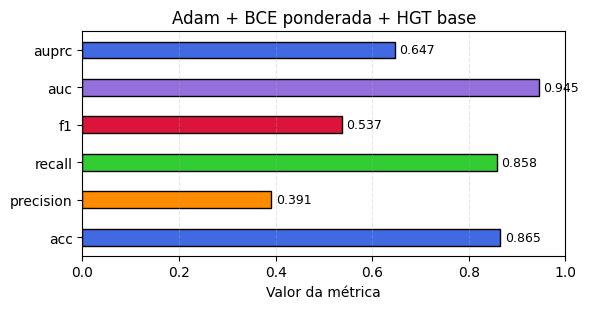

{'modelo': 'Adam + BCE ponderada + HGT base', 'acc': 0.8653748087710352, 'precision': 0.39063829787234045, 'recall': 0.8579439252336448, 'f1': 0.5368421052631579, 'auc': np.float64(0.944538616934272), 'auprc': np.float64(0.6467135030686313)}
0.8653748087710352


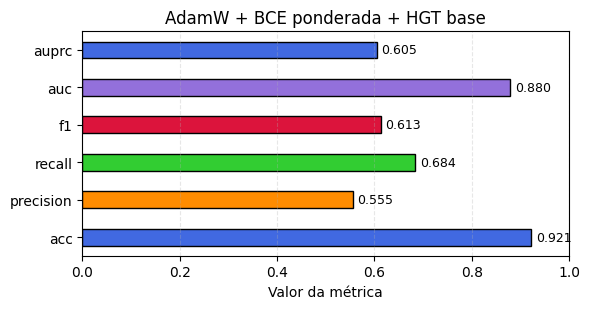

{'modelo': 'AdamW + BCE ponderada + HGT base', 'acc': 0.9214686384497706, 'precision': 0.5553869499241275, 'recall': 0.6841121495327103, 'f1': 0.6130653266331658, 'auc': np.float64(0.8795315219594714), 'auprc': np.float64(0.604639443451618)}
0.9214686384497706


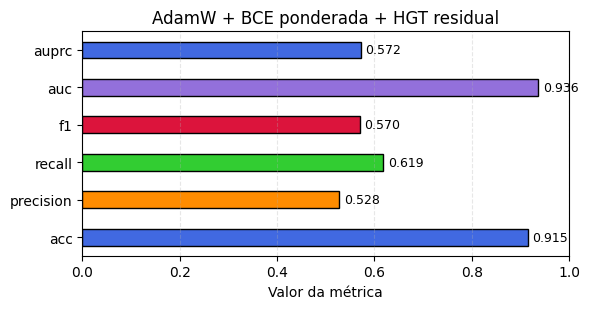

{'modelo': 'AdamW + BCE ponderada + HGT residual', 'acc': 0.9150093489716131, 'precision': 0.5279106858054227, 'recall': 0.6186915887850467, 'f1': 0.5697074010327022, 'auc': np.float64(0.9360012302616403), 'auprc': np.float64(0.5718549716065641)}
0.9150093489716131


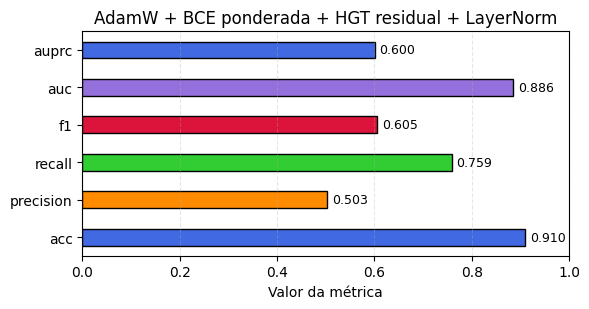

{'modelo': 'AdamW + BCE ponderada + HGT residual + LayerNorm', 'acc': 0.9099099099099099, 'precision': 0.5030978934324659, 'recall': 0.7588785046728972, 'f1': 0.6050670640834576, 'auc': np.float64(0.8855430277018572), 'auprc': np.float64(0.6004127101191391)}
0.9099099099099099


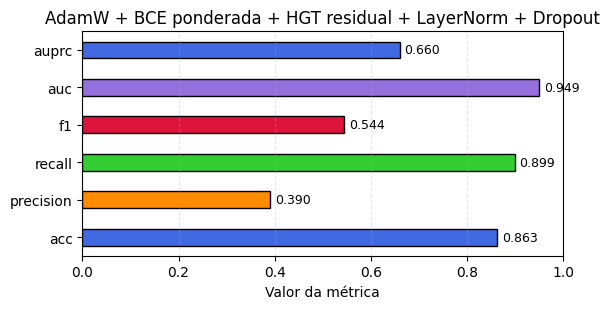

{'modelo': 'AdamW + BCE ponderada + HGT residual + LayerNorm + Dropout', 'acc': 0.8631650518442971, 'precision': 0.39042207792207795, 'recall': 0.8990654205607477, 'f1': 0.5444255800792304, 'auc': np.float64(0.9493701899216408), 'auprc': np.float64(0.6598661282633643)}
0.8631650518442971


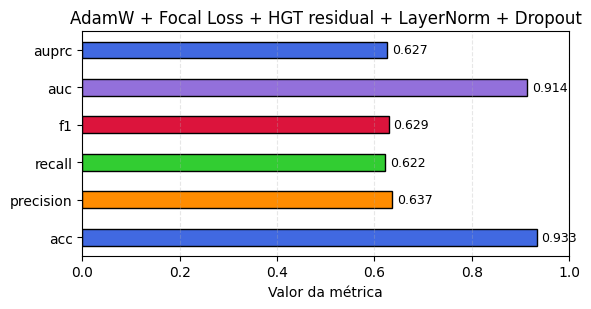

{'modelo': 'AdamW + Focal Loss + HGT residual + LayerNorm + Dropout', 'acc': 0.9333673295937447, 'precision': 0.6367112810707457, 'recall': 0.6224299065420561, 'f1': 0.6294896030245747, 'auc': np.float64(0.9143521204537987), 'auprc': np.float64(0.6266822196088614)}
0.9333673295937447


In [27]:
for d in resultados:
    new = d.copy()
    new.pop("modelo")
    plotar_metricas(
        new,
        titulo=d["modelo"],
        salvar_em=caminho + f"metricas_{d['modelo'].replace(' ', '_').replace('+', 'mais').replace('/', '_')}.png"
    )
    print(d)
    print(d['acc'])

# GNN

In [29]:
from torch_geometric.nn import HeteroConv, SAGEConv, Linear
import pandas as pd

In [30]:
class GNNEncoderSAGEHetero(nn.Module):
    def __init__(
        self,
        metadata,
        hidden_channels=64,
        num_layers=2,
        dropout=0.3,
        residual=False,
        usar_layernorm=False,
        ativacao="relu",
        aggr="sum"
    ):
        super().__init__()

        self.node_types = metadata[0]
        self.edge_types = metadata[1]
        self.residual = residual
        self.ativacao = ativacao
        self.dropout = nn.Dropout(dropout)

        # Projeta os atributos de cada tipo de nó para a mesma dimensão.
        self.projecoes = nn.ModuleDict({
            node_type: Linear(-1, hidden_channels)
            for node_type in self.node_types
        })

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            convs_por_relacao = {}

            for edge_type in self.edge_types:
                convs_por_relacao[edge_type] = SAGEConv(
                    (hidden_channels, hidden_channels),
                    hidden_channels
                )

            self.convs.append(
                HeteroConv(convs_por_relacao, aggr=aggr)
            )

            self.norms.append(
                nn.ModuleDict({
                    node_type: criar_normalizacao(hidden_channels, usar_layernorm)
                    for node_type in self.node_types
                })
            )

    def forward(self, x_dict, edge_index_dict):
        # Projeção inicial dos nós.
        x_dict = {
            node_type: aplicar_ativacao(
                self.projecoes[node_type](x),
                self.ativacao
            )
            for node_type, x in x_dict.items()
        }

        # Camadas GraphSAGE heterogêneas.
        for conv, norm_dict in zip(self.convs, self.norms):
            h_dict = conv(x_dict, edge_index_dict)
            novo_x_dict = {}

            for node_type, x in x_dict.items():
                h = h_dict.get(node_type, x)

                h = aplicar_ativacao(h, self.ativacao)
                h = self.dropout(h)

                if self.residual:
                    h = x + h

                h = norm_dict[node_type](h)
                novo_x_dict[node_type] = h

            x_dict = novo_x_dict

        return x_dict

In [31]:
class GNNFraudModel(nn.Module):
    def __init__(
        self,
        metadata,
        hidden_channels,
        edge_attr_dim,
        num_layers=2,
        dropout=0.3,
        residual=False,
        usar_layernorm=False,
        decoder="simples",
        ativacao="relu",
        aggr="sum"
    ):
        super().__init__()

        self.encoder = GNNEncoderSAGEHetero(
            metadata=metadata,
            hidden_channels=hidden_channels,
            num_layers=num_layers,
            dropout=dropout,
            residual=residual,
            usar_layernorm=usar_layernorm,
            ativacao=ativacao,
            aggr=aggr
        )

        self.classificador = ClassificadorArestaUnificado(
            hidden_channels=hidden_channels,
            edge_attr_dim=edge_attr_dim,
            decoder=decoder,
            dropout=dropout,
            usar_layernorm=usar_layernorm,
            ativacao=ativacao
        )

    def forward(self, data):
        rel = ("account", "transfere_para", "account")

        z_dict = self.encoder(data.x_dict, data.edge_index_dict)

        edge_index = data[rel].edge_index
        edge_attr = data[rel].edge_attr

        src = edge_index[0]
        dst = edge_index[1]

        z_src = z_dict["account"][src]
        z_dst = z_dict["account"][dst]

        logits = self.classificador(z_src, z_dst, edge_attr)

        return logits

In [32]:
def criar_modelo_gnn(
    grafo,
    hidden_channels=64,
    num_layers=2,
    dropout=0.3,
    residual=False,
    usar_layernorm=False,
    decoder="simples",
    ativacao="relu",
    aggr="sum",
    device="cpu"
):
    rel = ("account", "transfere_para", "account")
    edge_attr_dim = grafo[rel].edge_attr.shape[1]

    model = GNNFraudModel(
        metadata=grafo.metadata(),
        hidden_channels=hidden_channels,
        edge_attr_dim=edge_attr_dim,
        num_layers=num_layers,
        dropout=dropout,
        residual=residual,
        usar_layernorm=usar_layernorm,
        decoder=decoder,
        ativacao=ativacao,
        aggr=aggr
    )

    return model.to(device)

In [37]:
# ============================================================
# CONFIGURAÇÃO DO GNN
# ============================================================
# Esta configuração usa os principais parâmetros do modelo HGT base,
# mas sem num_heads, pois GraphSAGE não possui cabeças de atenção.
# ============================================================

config_gnn = {
    "nome": "AdamW + BCE ponderada + GNN GraphSAGE heterogêneo",
    "seed": 42,
    "hidden_channels": 64,
    "num_layers": 2,
    "dropout": 0.3,
    "residual": False,
    "usar_layernorm": False,
    "decoder": "simples",
    "ativacao": "relu",
    "loss": "bce_ponderada",
    "pos_weight": 10.0,
    "otimizador": "adamw",
    "lr": 0.01,
    "weight_decay": 1e-4,
    "num_epochs": 300,
    "threshold": 0.5,
    "aggr": "sum"
}

In [38]:
# ============================================================
# TREINAMENTO DO GNN
# ============================================================

definir_seed(config_gnn["seed"])

model_gnn = criar_modelo_gnn(
    grafo=grafo_treino,
    hidden_channels=config_gnn["hidden_channels"],
    num_layers=config_gnn["num_layers"],
    dropout=config_gnn["dropout"],
    residual=config_gnn["residual"],
    usar_layernorm=config_gnn["usar_layernorm"],
    decoder=config_gnn["decoder"],
    ativacao=config_gnn["ativacao"],
    aggr=config_gnn["aggr"],
    device=device
)

criterion_gnn = criar_loss(
    nome_loss=config_gnn["loss"],
    pos_weight=config_gnn["pos_weight"],
    device=device
)

optimizer_gnn = criar_otimizador(
    model_gnn,
    nome_otimizador=config_gnn["otimizador"],
    lr=config_gnn["lr"],
    weight_decay=config_gnn["weight_decay"]
)

print("Experimento:", config_gnn["nome"])
print(model_gnn)
print("-" * 60)

model_gnn, historico_gnn = treinar_modelo(
    model=model_gnn,
    grafo_treino=grafo_treino,
    grafo_validacao=grafo_validacao,
    criterion=criterion_gnn,
    optimizer=optimizer_gnn,
    num_epochs=config_gnn["num_epochs"],
    threshold=config_gnn["threshold"]
)

Experimento: AdamW + BCE ponderada + GNN GraphSAGE heterogêneo
GNNFraudModel(
  (encoder): GNNEncoderSAGEHetero(
    (dropout): Dropout(p=0.3, inplace=False)
    (projecoes): ModuleDict(
      (account): Linear(-1, 64, bias=True)
      (bank): Linear(-1, 64, bias=True)
      (entity): Linear(-1, 64, bias=True)
    )
    (convs): ModuleList(
      (0-1): 2 x HeteroConv(num_relations=5)
    )
    (norms): ModuleList(
      (0-1): 2 x ModuleDict(
        (account): Identity()
        (bank): Identity()
        (entity): Identity()
      )
    )
  )
  (classificador): ClassificadorArestaUnificado(
    (linear1): Linear(in_features=184, out_features=128, bias=True)
    (norm1): Identity()
    (drop1): Dropout(p=0.3, inplace=False)
    (linear2): Linear(in_features=128, out_features=64, bias=True)
    (norm2): Identity()
    (drop2): Dropout(p=0.3, inplace=False)
    (saida): Linear(in_features=64, out_features=1, bias=True)
  )
)
------------------------------------------------------------


In [39]:
# ============================================================
# AVALIAÇÃO DO GNN NO CONJUNTO DE TESTE
# ============================================================

metricas_gnn = avaliar(
    model_gnn,
    grafo_teste,
    tipo="Teste - GNN GraphSAGE",
    threshold=config_gnn["threshold"]
)

resultado_gnn_df = pd.DataFrame([
    {
        "modelo": config_gnn["nome"],
        "accuracy": metricas_gnn["acc"],
        "precision": metricas_gnn["precision"],
        "recall": metricas_gnn["recall"],
        "f1": metricas_gnn["f1"],
        "auc": metricas_gnn["auc"],
        "auprc": metricas_gnn["auprc"]
    }
])

display(resultado_gnn_df)

Teste - GNN GraphSAGE: acc=0.856 | precision=0.378 | recall=0.903 | f1=0.533 | auc=0.950 | auprc=0.684


,modelo,accuracy,precision,recall,f1,auc,auprc
0,AdamW + BCE ponderada + GNN GraphSAGE heterogêneo,0.855856,0.377639,0.902804,0.532525,0.949939,0.684415


### Observação sobre o modelo unificado

O HGT base e o HGT residual agora usam a mesma classe `HGTFraudModel`. A diferença entre as variações é definida apenas pelos parâmetros:

- `residual`: ativa ou remove a conexão residual;
- `usar_layernorm`: ativa ou remove a LayerNorm;
- `dropout`: controla a regularização;
- `decoder`: usa o classificador simples ou o classificador relacional;
- `loss`: permite alternar entre BCE ponderada e Focal Loss;
- `otimizador`: permite alternar entre Adam e AdamW.
